In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/iamsouravbanerjee/airline-dataset/Airline Dataset Updated.csv
/kaggle/input/datasets/iamsouravbanerjee/airline-dataset/Airline Dataset Updated - v2.csv
/kaggle/input/datasets/iamsouravbanerjee/airline-dataset/Airline Dataset.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/iamsouravbanerjee/airline-dataset/Airline Dataset Updated - v2.csv')

In [3]:
df

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Fransisco Hazeldine,On Time
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Marla Parsonage,On Time
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Rhonda Amber,On Time
3,BRS38V,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,9/16/2022,YND,Kacie Commucci,Delayed
4,9kvTLo,Bay,Pencost,Male,21,China,Gillespie Field,US,United States,NAM,North America,2/25/2022,SEE,Ebonee Tree,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98614,hnGQ62,Gareth,Mugford,Male,85,China,Hasvik Airport,NO,Norway,EU,Europe,12-11-2022,HAA,Pammie Kingscote,Cancelled
98615,2omEzh,Kasey,Benedict,Female,19,Russia,Ampampamena Airport,MG,Madagascar,AF,Africa,10/30/2022,IVA,Dorice Lochran,Cancelled
98616,VUPiVG,Darrin,Lucken,Male,65,Indonesia,Albacete-Los Llanos Airport,ES,Spain,EU,Europe,09-10-2022,ABC,Gearalt Main,On Time
98617,E47NtS,Gayle,Lievesley,Female,34,China,Gagnoa Airport,CI,Côte d'Ivoire,AF,Africa,10/26/2022,GGN,Judon Chasle,Cancelled


In [4]:
df.shape

(98619, 15)

In [6]:
df.isnull().sum()

Passenger ID            0
First Name              0
Last Name               0
Gender                  0
Age                     0
Nationality             0
Airport Name            0
Airport Country Code    0
Country Name            0
Airport Continent       0
Continents              0
Departure Date          0
Arrival Airport         0
Pilot Name              0
Flight Status           0
dtype: int64

In [10]:
df['Passenger ID'].count()

np.int64(98619)

In [12]:
df.dtypes

Passenger ID            object
First Name              object
Last Name               object
Gender                  object
Age                      int64
Nationality             object
Airport Name            object
Airport Country Code    object
Country Name            object
Airport Continent       object
Continents              object
Departure Date          object
Arrival Airport         object
Pilot Name              object
Flight Status           object
dtype: object

In [14]:
df['Age'].head()

0    62
1    62
2    67
3    71
4    21
Name: Age, dtype: int64

In [20]:
df['Age'].describe

<bound method NDFrame.describe of 0        62
1        62
2        67
3        71
4        21
         ..
98614    85
98615    19
98616    65
98617    34
98618    10
Name: Age, Length: 98619, dtype: int64>

In [22]:
print('Mean Age on the plane ' , df['Age'].mean())

Mean Age on the plane  45.50402052342855


In [25]:
df['Gender'].value_counts()

Gender
Male      49598
Female    49021
Name: count, dtype: int64

In [33]:
df['Departure Date'] = pd.to_datetime(df['Departure Date'], format='mixed')

In [34]:
df['Departure Date']

0       2022-06-28
1       2022-12-26
2       2022-01-18
3       2022-09-16
4       2022-02-25
           ...    
98614   2022-12-11
98615   2022-10-30
98616   2022-09-10
98617   2022-10-26
98618   2022-04-16
Name: Departure Date, Length: 98619, dtype: datetime64[ns]

In [35]:
df['Departure Date'].value_counts().head(1)

Departure Date
2022-07-22    325
Name: count, dtype: int64

In [36]:
df['Weekday'] = df['Departure Date'].dt.day_name()
df['Weekday'].value_counts()

Weekday
Sunday       14289
Thursday     14227
Friday       14227
Tuesday      14048
Monday       14032
Wednesday    13939
Saturday     13857
Name: count, dtype: int64

In [37]:
df['Month'] = df['Departure Date'].dt.month
df['Day'] = df['Departure Date'].dt.day
df['Weekday'] = df['Departure Date'].dt.day_name()

In [38]:
df['Nationality'].value_counts().head(10)

Nationality
China            18317
Indonesia        10559
Russia            5693
Philippines       5239
Brazil            3791
Portugal          3299
Poland            3245
France            2907
Sweden            2397
United States     2105
Name: count, dtype: int64

In [39]:
df['Flight Status'].value_counts()

Flight Status
Cancelled    32942
On Time      32846
Delayed      32831
Name: count, dtype: int64

In [40]:
df['Airport Name'].value_counts().head(10)

Airport Name
San Pedro Airport       43
Santa Maria Airport     38
Böblingen Flugfeld      36
Santa Ana Airport       35
San Fernando Airport    31
Mae Hong Son Airport    29
Cochrane Airport        28
Santa Rosa Airport      28
Capital City Airport    28
La Florida Airport      27
Name: count, dtype: int64

In [41]:
df['Age'].describe()

count    98619.000000
mean        45.504021
std         25.929849
min          1.000000
25%         23.000000
50%         46.000000
75%         68.000000
max         90.000000
Name: Age, dtype: float64

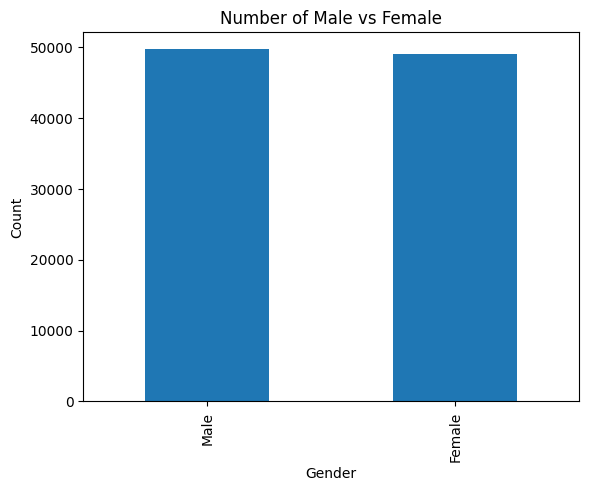

In [29]:
import matplotlib.pyplot as plt
df['Gender'].value_counts().plot(kind='bar')
plt.title('Number of Male vs Female')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

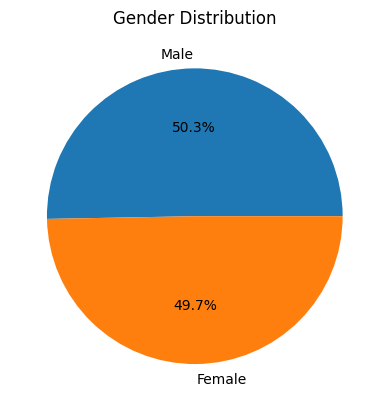

In [30]:
import matplotlib.pyplot as plt

df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Gender Distribution')
plt.ylabel('') 

plt.show()

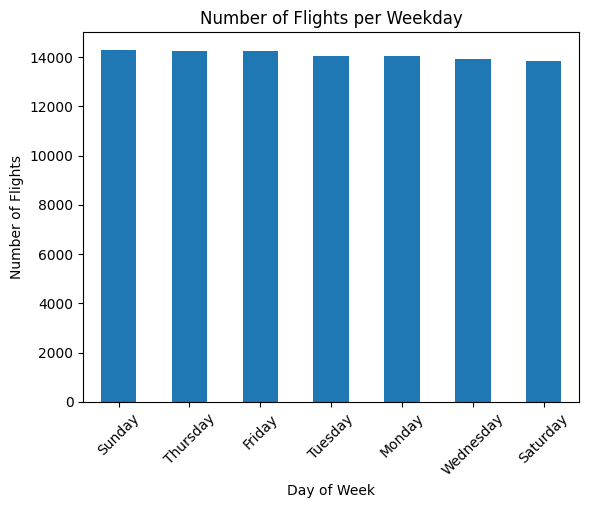

In [43]:
import matplotlib.pyplot as plt

df['Weekday'].value_counts().plot(kind='bar')

plt.title('Number of Flights per Weekday')
plt.xlabel('Day of Week')
plt.ylabel('Number of Flights')

plt.xticks(rotation=45)

plt.show()